# Static and dynamic RSA distance matching

This notebook animates how the dynamic pairwise stimulus distances approach the static pairwise stimulus distances. It repeats the same animation for:

1. all matched stimuli;
2. the most exciting static stimuli;
3. the least exciting static stimuli; and
4. a seeded random subset with the same number of stimuli.

The top, bottom, and random selections use the same population-response ranking and size-matched random-control logic as the manifold-dynamics analysis. Choose `static_response` below to analyze the standard last-frame image, the 2000 ms frame, or the 2250 ms frame.

In [ ]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import display


# Locate the repository whether the notebook starts in the project root or scripts/.
working_directory = Path.cwd().resolve()
project_candidates = (working_directory, *working_directory.parents)
PROJECT_ROOT = next(
    candidate for candidate in project_candidates
    if (candidate / "config.yaml").is_file()
)
ENV = os.getenv("MY_ENV", "tiziano_mac_mini")

with open(PROJECT_ROOT / "config.yaml", "r") as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]["paths"]
for source_path in (paths["src_path"], paths["useful_stuff_path"]):
    if source_path not in sys.path:
        sys.path.append(source_path)
    # end if source_path
# end for source_path
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.general_utils.utils import TimeSeries
from project_specific_utils import (
    load_natraster,
    match_timed_static_movie_rasters,
    population_response_scores,
    select_manifold_subsets,
)

## Configuration

`static_response` accepts `"last_frame"`, `"2000ms"`, or `"2250ms"`. `rdm_metric` controls the distance used in every animation. `static_pca_time_ms` and `dynamic_pca_time_ms` select the PCA snapshots; leave the dynamic value as `None` to align it automatically to the selected movie-frame onset plus the static PCA time. Time windows are half-open: `(start_ms, end_ms)` includes the start and excludes the end. `static_window_ms` also defines the population-response window used to rank the most and least exciting stimuli. `subset_size` controls the top, bottom, and size-matched random groups, and `random_seed` makes the random group reproducible. `good_channels` uses one-based MATLAB channel numbers with both endpoints included; set it to `None` to use every channel.

In [135]:
@dataclass
class Cfg:
    static_exp_name: str = "baby1_260718to27"#  "red_20260726to27" # 
    dynamic_exp_name: str = "baby1_260716to24" #  "red_20260720to24" #
    # Options: "last_frame", "2000ms", or "2250ms".
    static_response: str = "last_frame"
    good_channels: tuple[int, int] | None = (84, 186) # None #None # (101, 109) # 
    use_reliable_channels: bool = True
    reliable_channels_config: Path | None = None
    reliable_channels_key: str | None = None

    source_fs: float = 1000
    new_fs: float = 100
    rdm_metric: str = "euclidean"
    static_pca_time_ms: float = 260
    dynamic_pca_time_ms: float | None = None
    static_window_ms: tuple[float, float] = (100, 500)
    # Use None to shift static_window_ms to the chosen movie-frame time.
    # A tuple overrides automatic alignment, e.g. (60, 200) from movie onset.
    dynamic_window_ms: tuple[float, float] | None = (2500, 2900)
    subset_size: int = 50
    random_seed: int = 0

    correlation_bin_count: int = 20
    ranked_stimuli_to_show: int = 15
    figure_dpi: int = 120
# EOC


cfg = Cfg()
x_lim, y_lim = [0, 5], [0, 5]
frame_time_ms_by_static_response = {
    "last_frame": 2500,
    "2000ms": 2000,
    "2250ms": 2250,
}
if cfg.static_response not in frame_time_ms_by_static_response:
    raise ValueError(
        "static_response must be 'last_frame', '2000ms', or '2250ms'."
    )
# end if invalid static_response

selected_frame_time_ms = frame_time_ms_by_static_response[
    cfg.static_response
]
analysis_dynamic_pca_time_ms = (
    selected_frame_time_ms + cfg.static_pca_time_ms
    if cfg.dynamic_pca_time_ms is None
    else cfg.dynamic_pca_time_ms
)
if cfg.dynamic_window_ms is None:
    analysis_dynamic_window_ms = tuple(
        selected_frame_time_ms + time_ms
        for time_ms in cfg.static_window_ms
    )
else:
    analysis_dynamic_window_ms = cfg.dynamic_window_ms
# end if cfg.dynamic_window_ms is None

plt.rcParams["figure.dpi"] = cfg.figure_dpi
cfg

Cfg(static_exp_name='baby1_260718to27', dynamic_exp_name='baby1_260716to24', static_response='last_frame', good_channels=(84, 186), use_reliable_channels=True, reliable_channels_config=None, reliable_channels_key=None, source_fs=1000, new_fs=100, rdm_metric='euclidean', static_pca_time_ms=260, dynamic_pca_time_ms=None, static_window_ms=(100, 500), dynamic_window_ms=(2500, 2900), subset_size=50, random_seed=0, correlation_bin_count=20, ranked_stimuli_to_show=15, figure_dpi=120)

## Load and align the natraster responses

The loader first applies `good_channels` and optionally intersects that range with the static-session reliability list. The same retained physical channels are loaded from both sessions. It then aligns the standard `img_`, `img_2000ms_`, `img_2250ms_`, and `vid_` conditions by the identity that follows their prefix. `cfg.static_response` selects one aligned static condition. Static order is preserved, and stimuli missing from any of the four conditions are removed.

In [136]:
data_dir = Path(paths["data_path"]) / "data"
static_path = data_dir / f"{cfg.static_exp_name}_natraster_img.mat"
dynamic_path = data_dir / f"{cfg.dynamic_exp_name}_natraster_vid.mat"

# By default, use the reliability list estimated from the static session.
reliable_channels_config = None
reliable_channels_key = None
if cfg.use_reliable_channels:
    reliable_channels_config = (
        cfg.reliable_channels_config
        or PROJECT_ROOT / "reliable_channels.yaml"
    )
    reliable_channels_key = (
        cfg.reliable_channels_key or cfg.static_exp_name
    )
# end if cfg.use_reliable_channels

# Apply the identical physical-channel selection to both sessions.
loaded_static, static_names, static_channel_numbers = load_natraster(
    static_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
loaded_dynamic, dynamic_names, dynamic_channel_numbers = load_natraster(
    dynamic_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
if not np.array_equal(static_channel_numbers, dynamic_channel_numbers):
    raise ValueError(
        "Static and dynamic sessions retained different physical channels."
    )
# end if retained channels differ
channel_numbers = static_channel_numbers

(
    last_frame_rasters,
    dynamic_rasters,
    image_2000ms_rasters,
    image_2250ms_rasters,
    shared_stimuli,
    aligned_names,
) = match_timed_static_movie_rasters(
    loaded_static, static_names, loaded_dynamic, dynamic_names,
)

static_rasters_by_response = {
    "last_frame": last_frame_rasters,
    "2000ms": image_2000ms_rasters,
    "2250ms": image_2250ms_rasters,
}
static_names_by_response = {
    "last_frame": aligned_names["image"],
    "2000ms": aligned_names["image_2000ms"],
    "2250ms": aligned_names["image_2250ms"],
}
static_rasters = static_rasters_by_response[cfg.static_response]
selected_static_names = static_names_by_response[cfg.static_response]

if static_rasters.shape[0] != dynamic_rasters.shape[0]:
    raise ValueError(
        "Static and dynamic sessions must contain the same physical channels."
    )
# end if channel counts differ

print(f"Static natraster:  {static_path}")
print(f"Dynamic natraster: {dynamic_path}")
print(f"Reliable-channel filter: {cfg.use_reliable_channels}")
if cfg.use_reliable_channels:
    print(f"Reliability config: {reliable_channels_config}")
    print(f"Reliability key: {reliable_channels_key}")
# end if cfg.use_reliable_channels
print(
    f"Selected static response: {cfg.static_response} "
    f"({selected_frame_time_ms:g} ms movie frame)"
)
print(
    "First aligned pair:", selected_static_names[0],
    "<->", aligned_names["movie"][0],
)
print(f"Matched stimuli: {len(shared_stimuli)}")
print(f"Selected MATLAB channels: {channel_numbers.tolist()}")
print(f"Selected channel count: {len(channel_numbers)}")
print("Static shape: ", static_rasters.shape, "(channels, time, stimuli)")
print("Dynamic shape:", dynamic_rasters.shape, "(channels, time, stimuli)")

Static natraster:  /Users/tizianocausin/sd_local/data/baby1_260718to27_natraster_img.mat
Dynamic natraster: /Users/tizianocausin/sd_local/data/baby1_260716to24_natraster_vid.mat
Reliable-channel filter: True
Reliability config: /Users/tizianocausin/Desktop/static_dynamic/reliable_channels.yaml
Reliability key: baby1_260718to27
Selected static response: last_frame (2500 ms movie frame)
First aligned pair: img_0_0_41171.jpg <-> vid_0_0_41171.mp4
Matched stimuli: 100
Selected MATLAB channels: [101, 102, 103, 104, 105, 106, 107, 108, 109, 121, 122, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 158, 159, 160, 161, 162, 163, 164, 165]
Selected channel count: 30
Static shape:  (30, 1000, 100) (channels, time, stimuli)
Dynamic shape: (30, 3500, 100) (channels, time, stimuli)


## Select most exciting, least exciting, and random stimuli

As in the manifold-dynamics analysis, the static population response is averaged across channels and across `cfg.static_window_ms` for every stimulus. The `top` and `bottom` groups retain the highest and lowest scores. `random_001` is sampled without replacement, uses the same `cfg.subset_size`, and is reproducible through `cfg.random_seed`. The same stimulus indices are applied to the matched static and dynamic rasters.

In [137]:
# Rank stimuli by their mean static population response.
static_population_scores = population_response_scores(
    static_rasters, cfg.source_fs, cfg.static_window_ms,
)
stimulus_subsets = select_manifold_subsets(
    static_population_scores,
    cfg.subset_size,
    n_random_sets=1,
    rng=np.random.default_rng(cfg.random_seed),
)
most_exciting_indices = stimulus_subsets["top"]
least_exciting_indices = stimulus_subsets["bottom"]
random_indices = stimulus_subsets["random_001"]

print(f"Most exciting stimuli: {len(most_exciting_indices)}")
print(f"Least exciting stimuli: {len(least_exciting_indices)}")
print(f"Random size-matched stimuli: {len(random_indices)}")

Most exciting stimuli: 50
Least exciting stimuli: 50
Random size-matched stimuli: 50


## Compute RDM time series

Every group uses `cfg.rdm_metric`. Each subset is indexed before RDM construction, so every scatter point is one pairwise distance among stimuli in that group.

In [138]:
dynamic = TimeSeries(dynamic_rasters, cfg.source_fs)
dynamic.resample(cfg.new_fs)
static = TimeSeries(static_rasters, cfg.source_fs)
static.resample(cfg.new_fs)
drsa_obj = dRSA(cfg.rdm_metric)
drsa_obj.compute_both_RDM_timeseries(dynamic, static)

# Build the same RDM time series after restricting both conditions to each subset.
most_exciting_dynamic = TimeSeries(
    dynamic.array[:, :, most_exciting_indices], cfg.new_fs,
)
most_exciting_static = TimeSeries(
    static.array[:, :, most_exciting_indices], cfg.new_fs,
)
most_exciting_drsa_obj = dRSA(cfg.rdm_metric)
most_exciting_drsa_obj.compute_both_RDM_timeseries(
    most_exciting_dynamic, most_exciting_static,
)

least_exciting_dynamic = TimeSeries(
    dynamic.array[:, :, least_exciting_indices], cfg.new_fs,
)
least_exciting_static = TimeSeries(
    static.array[:, :, least_exciting_indices], cfg.new_fs,
)
least_exciting_drsa_obj = dRSA(cfg.rdm_metric)
least_exciting_drsa_obj.compute_both_RDM_timeseries(
    least_exciting_dynamic, least_exciting_static,
)

random_dynamic = TimeSeries(
    dynamic.array[:, :, random_indices], cfg.new_fs,
)
random_static = TimeSeries(
    static.array[:, :, random_indices], cfg.new_fs,
)
random_drsa_obj = dRSA(cfg.rdm_metric)
random_drsa_obj.compute_both_RDM_timeseries(
    random_dynamic, random_static,
)

## All matched stimuli

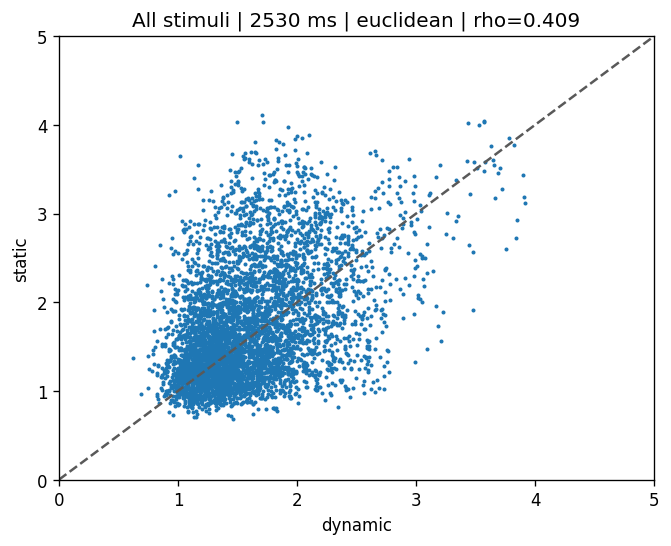

KeyboardInterrupt: 

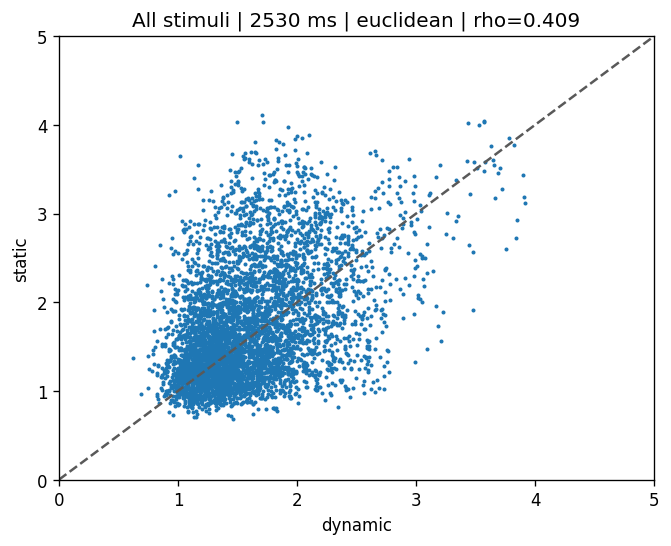

In [141]:
from scipy.stats import spearmanr
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import numpy as np
import time

static_RDM_ts = drsa_obj.get_RDM_timeseries("model")
dynamic_RDM_ts = drsa_obj.get_RDM_timeseries("signal")
target_static_RDM = static_RDM_ts[26]


fig, ax = plt.subplots()

for i, RDM in enumerate(dynamic_RDM_ts[200:]):
    rho, _ = spearmanr(RDM, target_static_RDM)
    ax.clear()

    ax.scatter(RDM, target_static_RDM, s=2)
    ax.plot(x_lim, y_lim, "--", color="0.35")

    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.set_ylabel("static")
    ax.set_xlabel("dynamic")
    dynamic_time_ms = (i + 200) * 1000 / cfg.new_fs
    ax.set_title(
        f"All stimuli | {dynamic_time_ms:g} ms | "
        f"{cfg.rdm_metric} | rho={rho:.3f}"
    )

    clear_output(wait=True)
    display(fig)

    time.sleep(0.1)
    if rho > .4:
        time.sleep(1)

plt.close(fig)

## Most exciting stimuli

In [ ]:
from scipy.stats import spearmanr
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import numpy as np
import time

static_RDM_ts = most_exciting_drsa_obj.get_RDM_timeseries("model")
dynamic_RDM_ts = most_exciting_drsa_obj.get_RDM_timeseries("signal")
target_static_RDM = static_RDM_ts[26]


fig, ax = plt.subplots()

for i, RDM in enumerate(dynamic_RDM_ts[200:]):
    rho, _ = spearmanr(RDM, target_static_RDM)
    ax.clear()

    ax.scatter(RDM, target_static_RDM, s=2)
    ax.plot(x_lim, y_lim, "--", color="0.35")

    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.set_ylabel("static")
    ax.set_xlabel("dynamic")
    dynamic_time_ms = (i + 200) * 1000 / cfg.new_fs
    ax.set_title(
        f"Most exciting | {dynamic_time_ms:g} ms | "
        f"{cfg.rdm_metric} | rho={rho:.3f}"
    )

    clear_output(wait=True)
    display(fig)

    time.sleep(0.1)
    if rho > .4:
        time.sleep(1)

plt.close(fig)

## Least exciting stimuli

In [ ]:
from scipy.stats import spearmanr
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import numpy as np
import time

static_RDM_ts = least_exciting_drsa_obj.get_RDM_timeseries("model")
dynamic_RDM_ts = least_exciting_drsa_obj.get_RDM_timeseries("signal")
target_static_RDM = static_RDM_ts[26]

fig, ax = plt.subplots()

for i, RDM in enumerate(dynamic_RDM_ts[200:]):
    rho, _ = spearmanr(RDM, target_static_RDM)
    ax.clear()

    ax.scatter(RDM, target_static_RDM, s=2)
    ax.plot(x_lim, y_lim, "--", color="0.35")

    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.set_ylabel("static")
    ax.set_xlabel("dynamic")
    dynamic_time_ms = (i + 200) * 1000 / cfg.new_fs
    ax.set_title(
        f"Least exciting | {dynamic_time_ms:g} ms | "
        f"{cfg.rdm_metric} | rho={rho:.3f}"
    )

    clear_output(wait=True)
    display(fig)

    time.sleep(0.1)
    if rho > .4:
        time.sleep(1)

plt.close(fig)

## Random size-matched stimuli

In [ ]:
from scipy.stats import spearmanr
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import numpy as np
import time

static_RDM_ts = random_drsa_obj.get_RDM_timeseries("model")
dynamic_RDM_ts = random_drsa_obj.get_RDM_timeseries("signal")
target_static_RDM = static_RDM_ts[26]

fig, ax = plt.subplots()

for i, RDM in enumerate(dynamic_RDM_ts[200:]):
    rho, _ = spearmanr(RDM, target_static_RDM)
    ax.clear()

    ax.scatter(RDM, target_static_RDM, s=2)
    ax.plot(x_lim, y_lim, "--", color="0.35")

    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.set_ylabel("static")
    ax.set_xlabel("dynamic")
    dynamic_time_ms = (i + 200) * 1000 / cfg.new_fs
    ax.set_title(
        f"Random size-matched | {dynamic_time_ms:g} ms | "
        f"{cfg.rdm_metric} | rho={rho:.3f}"
    )

    clear_output(wait=True)
    display(fig)

    time.sleep(0.1)
    if rho > .4:
        time.sleep(1)

plt.close(fig)

In [ ]:
%matplotlib inline
fig, ax = plt.subplots(
    2, 2, figsize=(10, 8),
    gridspec_kw={"wspace": 0.08, "hspace": 0.16},
)
alignment_offset = int(selected_frame_time_ms * cfg.new_fs / 1000)
d = drsa_obj.compute_dRSA()
ax[0, 0].imshow(
    d, origin="upper", aspect="auto", cmap="coolwarm",
    vmin=-1, vmax=1,
)
ax[0, 0].axhline(
    alignment_offset, color="red", linestyle=":", linewidth=1.5,
)
ax[0,0].set_title("all")
d = random_drsa_obj.compute_dRSA()
ax[0, 1].imshow(
    d, origin="upper", aspect="auto", cmap="coolwarm",
    vmin=-1, vmax=1,
)
ax[0, 1].axhline(
    alignment_offset, color="red", linestyle=":", linewidth=1.5,
)
ax[0,1].set_title("random")
d = most_exciting_drsa_obj.compute_dRSA()
ax[1, 0].imshow(
    d, origin="upper", aspect="auto", cmap="coolwarm",
    vmin=-1, vmax=1,
)
ax[1, 0].axhline(
    alignment_offset, color="red", linestyle=":", linewidth=1.5,
)
ax[1,0].set_title("top")
d = least_exciting_drsa_obj.compute_dRSA()
image = ax[1, 1].imshow(
    d, origin="upper", aspect="auto", cmap="coolwarm",
    vmin=-1, vmax=1,
)
ax[1, 1].axhline(
    alignment_offset, color="red", linestyle=":", linewidth=1.5,
)
ax[1,1].set_title("bottom")
fig.colorbar(
    image, ax=ax, label="RDM similarity (r)",
    shrink=0.9, pad=0.02,
)



## PCA snapshots for matched videos and images

PCA is fitted separately to the dynamic and static population responses at the configured timepoints. Rows are the same matched stimuli and columns are neural channels. Because PCA signs are arbitrary, each dynamic component is sign-aligned to its corresponding static component before plotting and reporting the matched-stimulus Pearson correlation. Both panels use exactly the same PC1 and PC2 limits, so a smaller dynamic cloud directly indicates contraction in the first two PCs.

PC1 matched-stimulus correlation: r=0.773
PC2 matched-stimulus correlation: r=0.476
Dynamic/static score spread: PC1=0.625, PC2=0.803
Dynamic/static two-PC RMS radius: 0.647


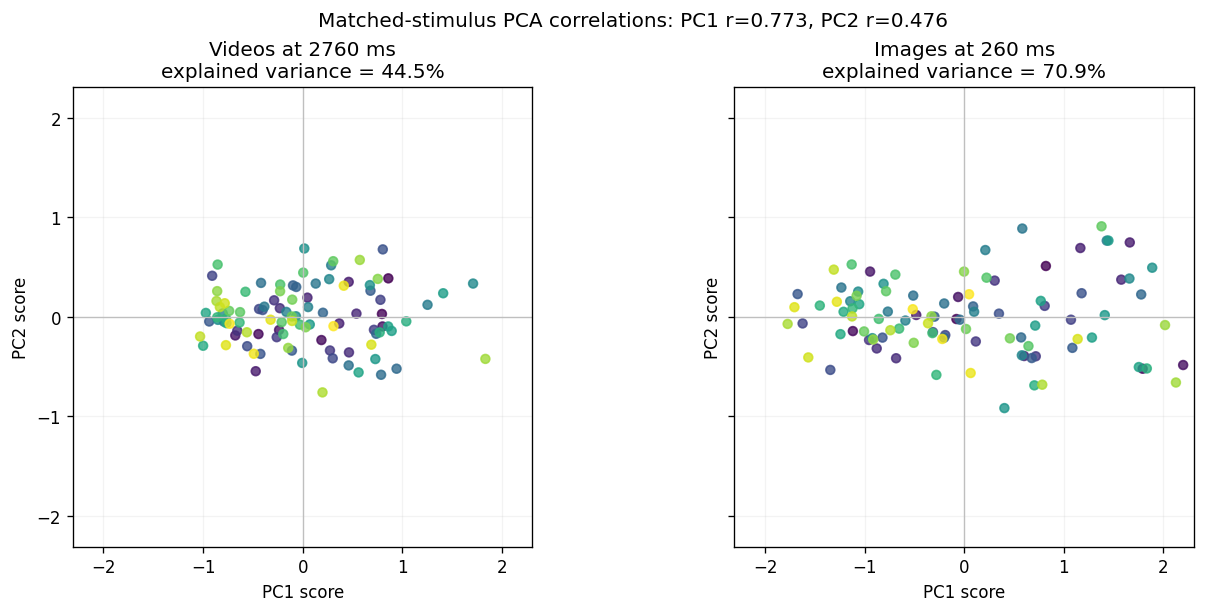

In [134]:
from sklearn.decomposition import PCA

# Convert the configured times to indices in the resampled responses.
static_pca_index = int(round(
    cfg.static_pca_time_ms * cfg.new_fs / 1000
))
dynamic_pca_index = int(round(
    analysis_dynamic_pca_time_ms * cfg.new_fs / 1000
))
if not 0 <= static_pca_index < static.array.shape[1]:
    raise ValueError("static_pca_time_ms is outside the static response.")
# end if static PCA time is invalid
if not 0 <= dynamic_pca_index < dynamic.array.shape[1]:
    raise ValueError("dynamic_pca_time_ms is outside the dynamic response.")
# end if dynamic PCA time is invalid

# PCA samples are matched stimuli and PCA features are neural channels.
static_response_matrix = static.array[:, static_pca_index, :].T
dynamic_response_matrix = dynamic.array[:, dynamic_pca_index, :].T
static_pca = PCA(n_components=2)
dynamic_pca = PCA(n_components=2)
static_pca_scores = static_pca.fit_transform(static_response_matrix)
dynamic_pca_scores = dynamic_pca.fit_transform(dynamic_response_matrix)

# Resolve PCA's arbitrary sign without changing score magnitudes.
pc_correlations = []
for component_index in range(2):
    correlation = np.corrcoef(
        static_pca_scores[:, component_index],
        dynamic_pca_scores[:, component_index],
    )[0, 1]
    if not np.isfinite(correlation):
        raise ValueError(
            f"PC{component_index + 1} correlation is not finite."
        )
    # end if correlation is invalid
    if correlation < 0:
        dynamic_pca_scores[:, component_index] *= -1
        correlation *= -1
    # end if PCA signs oppose each other
    pc_correlations.append(correlation)
# end for component_index

# Use identical symmetric axes so differences in cloud size remain visible.
score_limit = 1.05 * np.abs(np.concatenate((
    static_pca_scores.ravel(), dynamic_pca_scores.ravel(),
))).max()
if score_limit == 0:
    raise ValueError("PCA scores are constant at the selected timepoints.")
# end if PCA scores are constant
score_limits = (-score_limit, score_limit)
stimulus_colors = np.arange(static_pca_scores.shape[0])

figure, axes = plt.subplots(
    1, 2, figsize=(11, 5), sharex=True, sharey=True,
    constrained_layout=True,
)
axes[0].scatter(
    dynamic_pca_scores[:, 0], dynamic_pca_scores[:, 1],
    c=stimulus_colors, cmap="viridis", s=28, alpha=0.8,
)
axes[0].set_title(
    f"Videos at {analysis_dynamic_pca_time_ms:g} ms\n"
    f"explained variance = {dynamic_pca.explained_variance_ratio_.sum():.1%}"
)
axes[1].scatter(
    static_pca_scores[:, 0], static_pca_scores[:, 1],
    c=stimulus_colors, cmap="viridis", s=28, alpha=0.8,
)
axes[1].set_title(
    f"Images at {cfg.static_pca_time_ms:g} ms\n"
    f"explained variance = {static_pca.explained_variance_ratio_.sum():.1%}"
)
for axis in axes:
    axis.axhline(0, color="0.75", linewidth=0.8)
    axis.axvline(0, color="0.75", linewidth=0.8)
    axis.set(
        xlim=score_limits, ylim=score_limits, aspect="equal",
        xlabel="PC1 score", ylabel="PC2 score",
    )
    axis.grid(alpha=0.15)
# end for axis
figure.suptitle(
    f"Matched-stimulus PCA correlations: "
    f"PC1 r={pc_correlations[0]:.3f}, "
    f"PC2 r={pc_correlations[1]:.3f}"
)

# Quantify contraction using component spread and two-dimensional radius.
static_component_spread = static_pca_scores.std(axis=0)
dynamic_component_spread = dynamic_pca_scores.std(axis=0)
spread_ratio = dynamic_component_spread / static_component_spread
static_rms_radius = np.sqrt(np.mean(np.sum(static_pca_scores ** 2, axis=1)))
dynamic_rms_radius = np.sqrt(np.mean(np.sum(dynamic_pca_scores ** 2, axis=1)))
print(f"PC1 matched-stimulus correlation: r={pc_correlations[0]:.3f}")
print(f"PC2 matched-stimulus correlation: r={pc_correlations[1]:.3f}")
print(
    "Dynamic/static score spread: "
    f"PC1={spread_ratio[0]:.3f}, PC2={spread_ratio[1]:.3f}"
)
print(
    "Dynamic/static two-PC RMS radius: "
    f"{dynamic_rms_radius / static_rms_radius:.3f}"
)